In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)
from xgboost import XGBClassifier
import joblib

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

%matplotlib inline


In [2]:
DATA_PATH = Path('../data/processed/nykaa_campaign_features.csv')

df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Shape: 55555 rows x 53 columns


,Campaign_ID,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score,Spend,CTR,Conversion_Rate,CPC,CPA,ROAS,CPL,Lead_Rate,Lead_to_Conversion_Rate,Overall_Funnel_Efficiency,Impressions_per_Day,Clicks_per_Day,Leads_per_Day,Conversions_per_Day,Spend_per_Day,Year,Month,Quarter,Day_of_Week,Is_Weekend,Channel_Count,Is_Multichannel,Channel_Email,Channel_Facebook,Channel_Google,Channel_Instagram,Channel_WhatsApp,Channel_YouTube,Campaign_Type_Influencer,Campaign_Type_Paid Ads,Campaign_Type_SEO,Campaign_Type_Social Media,Target_Audience_Premium Shoppers,Target_Audience_Tier 2 City Customers,Target_Audience_Working Women,Target_Audience_Youth,Language_English,Language_Hindi,Language_Tamil,Customer_Segment_Premium Shoppers,Customer_Segment_Tier 2 City Customers,Customer_Segment_Working Women,Customer_Segment_Youth
0,NY-CMP-1000,21,57804,6156,3616,2355,1867515,111.03,6.14,20.98,261475.65,10.649782,38.255361,42.474927,111.03,7.142214,72.310744,58.739441,65.127212,4.074113,2752.571429,293.142857,172.190476,112.142857,12451.221429,2025,4,2,1,0,2,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
1,NY-CMP-1001,18,91801,3321,1971,1357,1046247,180.83,3.26,7.24,245386.31,3.617608,40.861186,73.889283,180.83,4.263673,124.498382,59.349593,68.848300,1.478197,5100.055556,184.500000,109.500000,75.388889,13632.572778,2025,4,2,6,1,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0
2,NY-CMP-1002,23,15536,2182,952,755,197055,90.60,1.88,25.03,68403.00,14.044799,34.601283,31.348763,90.60,2.880795,71.851891,43.629698,79.306723,4.859681,675.478261,94.869565,41.391304,32.826087,2974.043478,2025,1,1,1,0,3,1,0,0,1,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0
3,NY-CMP-1003,18,88114,8413,2231,947,376906,249.07,0.60,13.15,235869.29,9.547858,11.256389,28.036288,249.07,1.597944,105.723572,26.518483,42.447333,1.074744,4895.222222,467.388889,123.944444,52.611111,13103.849444,2025,6,2,2,0,3,1,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0
4,NY-CMP-1004,10,96871,3743,2060,1258,518296,228.60,0.80,7.29,287578.80,3.863901,33.609404,76.831098,228.60,1.802275,139.601359,55.036067,61.067961,1.298634,9687.100000,374.300000,206.000000,125.800000,28757.880000,2024,12,4,6,1,2,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0


In [3]:
df['Performance_Tier'] = pd.qcut(
    df['ROAS'],
    q=3,
    labels=['Low Performing', 'Medium Performing', 'High Performing']
)

tier_boundaries = pd.qcut(df['ROAS'], q=3).cat.categories
print("ROAS tertile boundaries used for the business rule:")
print(tier_boundaries)

print("\nClass balance:")
print(df['Performance_Tier'].value_counts())
print(df['Performance_Tier'].value_counts(normalize=True).round(3))


ROAS tertile boundaries used for the business rule:
IntervalIndex([(0.032, 1.374], (1.374, 3.583], (3.583, 75.441]], dtype='interval[float64, right]')

Class balance:
Performance_Tier
Low Performing       18519
High Performing      18519
Medium Performing    18517
Name: count, dtype: int64
Performance_Tier
Low Performing       0.333
High Performing      0.333
Medium Performing    0.333
Name: proportion, dtype: float64


In [4]:
validation = df.groupby('Performance_Tier')[['Revenue', 'Conversions', 'Conversion_Rate']].mean()

validation.style.format({
    'Revenue': '{:,.2f}',
    'Conversions': '{:,.2f}',
    'Conversion_Rate': '{:.2f}'
})

,Revenue,Conversions,Conversion_Rate
Performance_Tier,,,
Low Performing,"149,992.48",384.72,18.41
Medium Performing,"412,516.49",918.35,21.70
High Performing,"984,939.02","1,795.52",25.80


If `High Performing` shows the highest average `Revenue`, `Conversions` and
`Conversion_Rate` above (and `Low Performing` the lowest), the ROAS-based business rule is
behaving as expected and is safe to use as the modeling target.

In [6]:
ID_COLUMNS = ['Campaign_ID']
LABEL_SOURCE_COLUMNS = ['ROAS']  # the column the label was built from
LEAKAGE_EXCLUDE = [
    'ROAS', 'Revenue', 'ROI', 'Spend', 'Spend_per_Day', 'CPC', 'CPA', 'CPL',
]

drop_cols = sorted(set(ID_COLUMNS) | set(LEAKAGE_EXCLUDE) | {'Performance_Tier'})
drop_cols = [c for c in drop_cols if c in df.columns]

print("Columns excluded from X (ID + leakage + label itself):")
print(drop_cols)


Columns excluded from X (ID + leakage + label itself):
['CPA', 'CPC', 'CPL', 'Campaign_ID', 'Performance_Tier', 'ROAS', 'ROI', 'Revenue', 'Spend', 'Spend_per_Day']


In [7]:
X = df.drop(columns=drop_cols)
y_raw = df['Performance_Tier']

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

print("Class encoding:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {i} -> {cls}")

print(f"\nX shape: {X.shape}, y shape: {y.shape}")


Class encoding:
  0 -> High Performing
  1 -> Low Performing
  2 -> Medium Performing

X shape: (55555, 44), y shape: (55555,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("\nTrain class balance:", np.bincount(y_train) / len(y_train))
print("Test class balance: ", np.bincount(y_test) / len(y_test))


Train: (44444, 44), Test: (11111, 44)

Train class balance: [0.33334083 0.33334083 0.33331833]
Test class balance:  [0.33336333 0.33336333 0.33327333]


In [9]:
def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    numeric_cols = [c for c in X.columns if X[c].nunique() > 2]
    passthrough_cols = [c for c in X.columns if c not in numeric_cols]
    return ColumnTransformer(transformers=[
        ('scale', StandardScaler(), numeric_cols),
        ('passthrough', 'passthrough', passthrough_cols),
    ])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

MODEL_SPECS = {
    'Logistic Regression': {
        'estimator': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        'param_distributions': {
            'model__C': [0.01, 0.1, 1.0, 10.0],
            'model__penalty': ['l2'],
        },
    },
    'Decision Tree': {
        'estimator': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'param_distributions': {
            'model__max_depth': [4, 6, 8, 12, None],
            'model__min_samples_leaf': [1, 5, 10, 20],
            'model__criterion': ['gini', 'entropy'],
        },
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        'param_distributions': {
            'model__n_estimators': [200, 300, 400],
            'model__max_depth': [8, 12, 16, None],
            'model__min_samples_leaf': [1, 2, 4],
            'model__max_features': ['sqrt', 0.6, 1.0],
        },
    },
    'XGBoost': {
        'estimator': XGBClassifier(
            random_state=RANDOM_STATE, n_jobs=-1,
            objective='multi:softprob', num_class=3, eval_metric='mlogloss'
        ),
        'param_distributions': {
            'model__n_estimators': [200, 300, 400],
            'model__max_depth': [3, 5, 7],
            'model__learning_rate': [0.03, 0.05, 0.1],
            'model__subsample': [0.7, 0.85, 1.0],
            'model__colsample_bytree': [0.7, 0.85, 1.0],
        },
    },
}

print("Models configured:", list(MODEL_SPECS.keys()))


Models configured: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']


In [10]:
import time

def run_classification_experiment(
    X_train, y_train, model_name: str, cv=cv, n_iter: int = 5
):
    spec = MODEL_SPECS[model_name]
    preprocessor = build_preprocessor(X_train)

    pipeline = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', spec['estimator']),
    ])

    search = RandomizedSearchCV(
        pipeline,
        param_distributions=spec['param_distributions'],
        n_iter=n_iter,
        cv=cv,
        scoring='f1_macro',
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=2,
        refit=True,
    )

    # Start timer
    start_time = time.perf_counter()

    search.fit(X_train, y_train)

    # Stop timer
    training_time = time.perf_counter() - start_time

    return {
        'model_name': model_name,
        'pipeline': search.best_estimator_,
        'cv_f1_macro_mean': search.cv_results_['mean_test_score'][search.best_index_],
        'cv_f1_macro_std': search.cv_results_['std_test_score'][search.best_index_],
        'best_params': search.best_params_,
        'training_time': training_time,
    }

In [15]:
def evaluate_classification(pipeline, X_test, y_test, n_classes: int = 3) -> dict:
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)

    return {
        'Accuracy': round(accuracy_score(y_test, y_pred), 2),
        'Precision': round(precision_score(y_test, y_pred, average='macro'), 2),
        'Recall': round(recall_score(y_test, y_pred, average='macro'), 2),
        'F1': round(f1_score(y_test, y_pred, average='macro'), 2),
        'ROC_AUC': round(roc_auc_score(
            y_test, y_proba, multi_class='ovr', average='macro'
        ), 2),
    }

In [22]:
# Run all classification experiments
results = {}

for model_name in MODEL_SPECS:

    print(f"\n{'='*60}")
    print(f"Running: {model_name}")
    print(f"{'='*60}")

    results[model_name] = run_classification_experiment(
        X_train,
        y_train,
        model_name,
        cv=cv,
        n_iter=5
    )

print("\nAll models completed.")
print("Models in results:", list(results.keys()))


Running: Logistic Regression
Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END ...................model__C=0.01, model__penalty=l2; total time=  32.5s
[CV] END ...................model__C=0.01, model__penalty=l2; total time=  30.0s
[CV] END ...................model__C=0.01, model__penalty=l2; total time=  29.5s
[CV] END ...................model__C=0.01, model__penalty=l2; total time=  29.6s
[CV] END ...................model__C=0.01, model__penalty=l2; total time=  29.5s
[CV] END ....................model__C=0.1, model__penalty=l2; total time=  29.5s
[CV] END ....................model__C=0.1, model__penalty=l2; total time=  30.0s
[CV] END ....................model__C=0.1, model__penalty=l2; total time=  29.4s
[CV] END ....................model__C=0.1, model__penalty=l2; total time=  29.8s
[CV] END ....................model__C=0.1, model__penalty=l2; total time=  29.6s
[CV] END ....................model__C=1.0, model__penalty=l2; total time=  29.6s
[CV] END ..........

In [40]:
# Select the best model based on mean CV macro-F1

best_model_name = max(
    results,
    key=lambda model: results[model]["cv_f1_macro_mean"]
)

best_pipeline = results[best_model_name]["pipeline"]

print(f"Best Model: {best_model_name}")
print(
    f"Mean CV F1 (macro): "
    f"{results[best_model_name]['cv_f1_macro_mean']:.4f}"
)
print(
    f"CV F1 Std: "
    f"{results[best_model_name]['cv_f1_macro_std']:.4f}"
)
print("Best Parameters:")
print(results[best_model_name]["best_params"])

Best Model: Random Forest
Mean CV F1 (macro): 0.7837
CV F1 Std: 0.0044
Best Parameters:
{'model__n_estimators': 300, 'model__min_samples_leaf': 1, 'model__max_features': 0.6, 'model__max_depth': 8}


In [44]:
# Final model comparison
final_results = []

for model_name, model_info in results.items():

    pipeline = model_info["pipeline"]

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)

    final_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, average="macro"
        ),
        "Recall": recall_score(
            y_test, y_pred, average="macro"
        ),
        "F1": f1_score(
            y_test, y_pred, average="macro"
        ),
        "ROC_AUC": roc_auc_score(
            y_test,
            y_proba,
            multi_class="ovr",
            average="macro"
        ),
        "CV_F1_Mean": model_info["cv_f1_macro_mean"],
        "CV_F1_Std": model_info["cv_f1_macro_std"]
    })

final_comparison_df = pd.DataFrame(final_results)

display(
    final_comparison_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "CV_F1_Mean": "{:.4f}",
        "CV_F1_Std": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,CV_F1_Mean,CV_F1_Std
0,Logistic Regression,0.7916,0.7954,0.7916,0.7927,0.9318,0.7812,0.0037
1,Decision Tree,0.7905,0.8041,0.7905,0.7937,0.9309,0.7826,0.0059
2,Random Forest,0.7913,0.7988,0.7913,0.7935,0.9317,0.7837,0.0044
3,XGBoost,0.7912,0.7994,0.7912,0.7935,0.9320,0.7829,0.0045


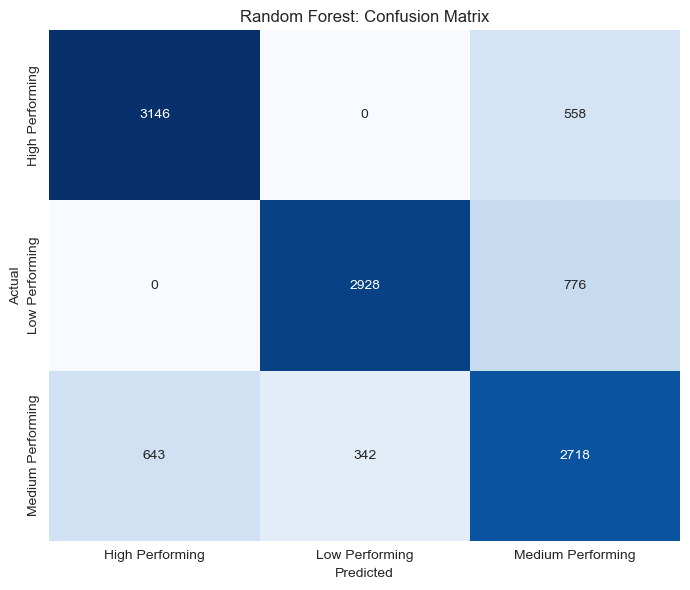

In [48]:
# Predictions from the selected best model

y_pred_best = best_pipeline.predict(X_test)

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_best)

cm_df = pd.DataFrame(
    cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_df,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False
)

plt.title(f"{best_model_name}: Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

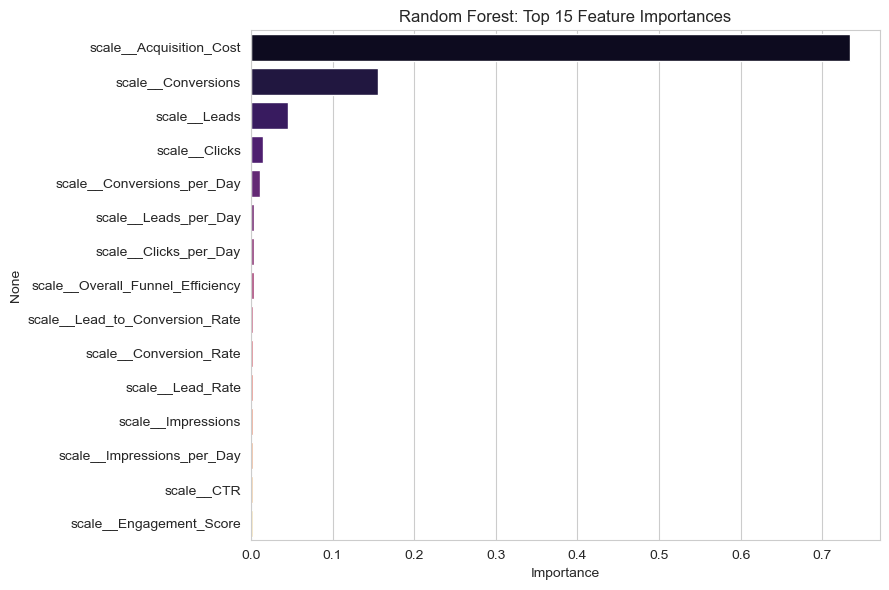

In [50]:
# Feature importance (tree models) or |coefficients| averaged across classes (linear model)
model_step = best_pipeline.named_steps['model']
preprocess_step = best_pipeline.named_steps['preprocess']
feature_names = preprocess_step.get_feature_names_out()

if hasattr(model_step, 'feature_importances_'):
    importances = pd.Series(model_step.feature_importances_, index=feature_names)
    title = f'{best_model_name}: Top 15 Feature Importances'
elif hasattr(model_step, 'coef_'):
    importances = pd.Series(np.abs(model_step.coef_).mean(axis=0), index=feature_names)
    title = f'{best_model_name}: Top 15 Mean |Coefficient| Across Classes'
else:
    importances = None

if importances is not None:
    importances = importances.sort_values(ascending=False).head(15)
    plt.figure(figsize=(9, 6))
    sns.barplot(x=importances.values, y=importances.index, palette='magma')
    plt.title(title)
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()


In [52]:
cv_scores = cross_validate(
    best_pipeline, X, y, cv=cv, scoring=['accuracy', 'f1_macro'], n_jobs=-1
)

print("Per-fold Accuracy:", np.round(cv_scores['test_accuracy'], 4))
print("Per-fold F1 (macro):", np.round(cv_scores['test_f1_macro'], 4))
print(f"\nMean Accuracy: {cv_scores['test_accuracy'].mean():.4f} "
      f"(+/- {cv_scores['test_accuracy'].std():.4f})")
print(f"Mean F1 (macro): {cv_scores['test_f1_macro'].mean():.4f} "
      f"(+/- {cv_scores['test_f1_macro'].std():.4f})")


Per-fold Accuracy: [0.79   0.7732 0.7817 0.7834 0.7894]
Per-fold F1 (macro): [0.792  0.7757 0.7836 0.7854 0.7903]

Mean Accuracy: 0.7835 (+/- 0.0061)
Mean F1 (macro): 0.7854 (+/- 0.0057)


In [56]:
from pathlib import Path
import joblib

MODELS_DIR = Path('../models')
REPORTS_DIR = Path('../reports')

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Save best classification model
model_path = MODELS_DIR / 'best_classifier_performance_tier.joblib'
joblib.dump(best_pipeline, model_path)

# Save label encoder
encoder_path = MODELS_DIR / 'performance_tier_label_encoder.joblib'
joblib.dump(label_encoder, encoder_path)

print(f"Saved best classifier ({best_model_name}) to: {model_path}")
print(f"Saved label encoder to: {encoder_path}")

# Save final model comparison
report_path = REPORTS_DIR / 'classification_model_comparison.csv'

final_comparison_df.to_csv(
    report_path,
    index=False
)

print(f"Saved full model comparison to: {report_path}")

Saved best classifier (Random Forest) to: ..\models\best_classifier_performance_tier.joblib
Saved label encoder to: ..\models\performance_tier_label_encoder.joblib
Saved full model comparison to: ..\reports\classification_model_comparison.csv
